Simulaciones

In [10]:
#Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


## Aceptación y Rechazo

Sea f una densidad objetivo de la cual queremos simular. Supongamos que
existe una densidad g (facil de simular) y una constante M > 0 tal que:
 - f (x) ≤ M · g(x) ∀x ∈ Soporte(f )
Entonces el siguiente algoritmo genera observaciones con densidad f :
 - 1 Generar Y ∼ g
 - 2 Generar U ∼ Uniforme(0, 1), independiente de Y
 - 3 Si U ≤
        f (Y )
        M·g(Y )
    , aceptar Y como muestra de f
 - 4 Si no, rechazar y regresar al paso 1

In [11]:

# ─────────────────────────────────────────────
# MÉTODO DE ACEPTACIÓN-RECHAZO
# ─────────────────────────────────────────────
# Objetivo: simular de f(x) ∝ x^2 * exp(-x/2)  en [0, ∞)
# (Gamma(3, 2) con parámetros forma=3, escala=2)
#
# Densidad propuesta g: Exponencial(lambda=0.5)
# Condición del teorema: f(x) ≤ M · g(x)  ∀x ∈ Soporte(f)
# ─────────────────────────────────────────────

# --- Densidades ---
def f(x):
    """Densidad objetivo (no normalizada): proporcional a Gamma(3,2)."""
    return stats.gamma.pdf(x, a=3, scale=2)

def g(x):
    """Densidad propuesta: Exponencial(lambda=0.5)."""
    return stats.expon.pdf(x, scale=2)   # scale = 1/lambda

# --- Constante M ---
# M = sup_x [ f(x) / g(x) ]
# Para Gamma(3,2) sobre Exponencial(lambda=0.5) se puede demostrar que M ≈ 2
# (encontrado numéricamente para ser rigurosos)
x_grid = np.linspace(1e-6, 30, 10_000)
M = np.max(f(x_grid) / g(x_grid)) * 1.01   # margen de seguridad del 1%
print(f"Constante M utilizada: {M:.4f}")


Constante M utilizada: 113.6250


#### Algoritmo de Aceptacion y rechazo

In [15]:

# --- Algoritmo de Aceptación-Rechazo ---
"""
    Genera n_samples muestras de f usando el método de aceptación-rechazo.

    Parámetros
    ----------
    n_samples  : int   – número de muestras deseadas
    M          : float – constante de cobertura (f ≤ M·g en todo el soporte)
    f          : callable – densidad objetivo
    g_sampler  : callable – genera una muestra de g y evalúa g en ella
                            retorna (Y, g(Y))
"""
def acceptance_rejection(n_samples, M, f, g_sampler):
    muestras = []
    intentos = 0

    while len(muestras) < n_samples:
        # Paso 1 – Generar Y ~ g
        Y, gY = g_sampler()

        # Paso 2 – Generar U ~ Uniforme(0,1), independiente de Y
        U = np.random.uniform(0, 1)

        intentos += 1

        # Paso 3 – Criterio de aceptación
        if U <= f(Y) / (M * gY):
            muestras.append(Y)          # aceptar Y como muestra de f
        # Paso 4 – Si no, rechazar y volver al paso 1

    tasa_acept = n_samples / intentos
    return np.array(muestras), tasa_acept


# Sampler de g: retorna (Y, g(Y)) con Y ~ Exponencial(lambda=0.5)
def g_sampler():
    Y = np.random.exponential(scale=2)
    return Y, g(Y)


#### Simulacion 

In [13]:

# --- Simulación ---
np.random.seed(42)
N = 10_000
muestras, tasa = acceptance_rejection(N, M, f, g_sampler)

print(f"Muestras generadas : {N}")
print(f"Tasa de aceptación : {tasa:.4f}  (teórica ≈ 1/M = {1/M:.4f})")
print(f"Media muestral     : {muestras.mean():.4f}  (teórica = 6.0)")
print(f"Varianza muestral  : {muestras.var():.4f}   (teórica = 12.0)")



Muestras generadas : 10000
Tasa de aceptación : 0.0087  (teórica ≈ 1/M = 0.0088)
Media muestral     : 5.9617  (teórica = 6.0)
Varianza muestral  : 11.9889   (teórica = 12.0)


#### Panel de visualizacion

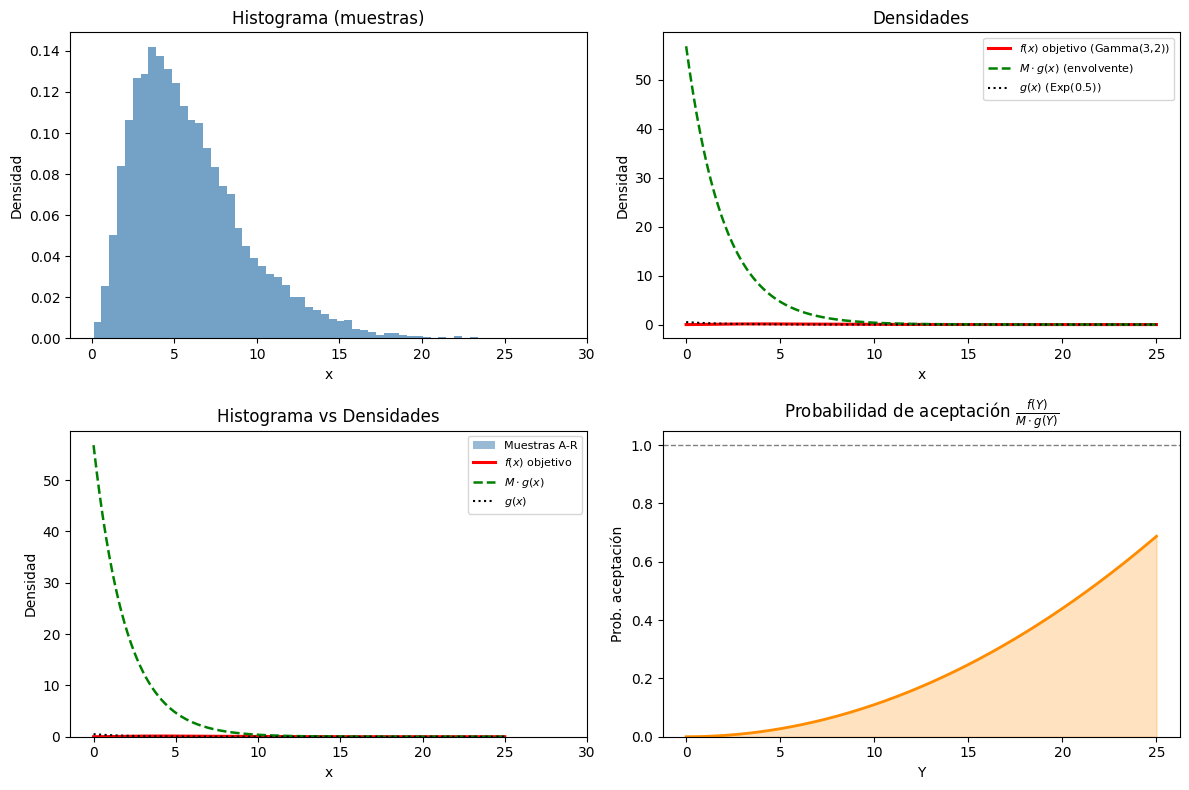

In [14]:
# --- Visualización (4 paneles) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
ax = axes.ravel()

# 1) Histograma solo
ax[0].hist(muestras, bins=60, density=True, color="steelblue", alpha=0.75)
ax[0].set_title("Histograma (muestras)")
ax[0].set_xlabel("x")
ax[0].set_ylabel("Densidad")

# 2) Densidades solo
ax[1].plot(x_plot, f(x_plot),   "r-",  lw=2.2, label=r"$f(x)$ objetivo (Gamma(3,2))")
ax[1].plot(x_plot, M*g(x_plot), "g--", lw=1.8, label=r"$M \cdot g(x)$ (envolvente)")
ax[1].plot(x_plot, g(x_plot),   "k:",  lw=1.5, label=r"$g(x)$ (Exp(0.5))")
ax[1].set_title("Densidades")
ax[1].set_xlabel("x")
ax[1].set_ylabel("Densidad")
ax[1].legend(fontsize=8)

# 3) Histograma vs densidades
ax[2].hist(muestras, bins=60, density=True, alpha=0.55, color="steelblue", label="Muestras A-R")
ax[2].plot(x_plot, f(x_plot),   "r-",  lw=2.2, label=r"$f(x)$ objetivo")
ax[2].plot(x_plot, M*g(x_plot), "g--", lw=1.8, label=r"$M \cdot g(x)$")
ax[2].plot(x_plot, g(x_plot),   "k:",  lw=1.5, label=r"$g(x)$")
ax[2].set_title("Histograma vs Densidades")
ax[2].set_xlabel("x")
ax[2].set_ylabel("Densidad")
ax[2].legend(fontsize=8)

# 4) Probabilidad de aceptación
ax[3].plot(x_plot, prob_acept, color="darkorange", lw=2)
ax[3].axhline(1, color="gray", lw=1, ls="--")
ax[3].fill_between(x_plot, prob_acept, alpha=0.25, color="darkorange")
ax[3].set_title(r"Probabilidad de aceptación $\frac{f(Y)}{M \cdot g(Y)}$")
ax[3].set_xlabel("Y")
ax[3].set_ylabel("Prob. aceptación")
ax[3].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()